# Setup Environment

In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
from scipy.stats import linregress, t
from scipy.spatial.distance import hamming
from scipy.stats import mannwhitneyu
import seaborn as sns
from adjustText import adjust_text

# Hyperparameters

In [ ]:
version = "1000ms"

In [ ]:
invalid_subjects = []
unnecessary_columns = []
if version == "1000ms":
    invalid_subjects = []
    # questions for practice trials
    unnecessary_columns =  ["Q113", "Q114", "Q115", "Q116", "Q117", "Q118", "Q119", "Q120", "Q121",
                 "Q140", "Q141", "Q142", "Q143", "Q144", "Q145", "Q146", "Q147", "Q148"]
    # columns for consent
    unnecessary_columns += ["Q18"]
    # columns for catch and demographics
    unnecessary_columns += ["Q266", "Q268", "Q269", "Q270"]
    unnecessary_columns += ["Q150", "Q181", "Q182"]
else:
    raise ValueError('version is not 1000ms!')

In [ ]:
invalid_subjects, unnecessary_columns

In [ ]:
scenes = ["Ball", "Supermarket", "Zoo", "Candle", "Shoe"]
colors = ["#E64E53", "#AA7C00", "#818A00", "#AD7291", "#2E9284"]
textcolor="#3F5661"
graycolor="#758D99"

In [ ]:
# ticks labels to be displayed in bar plot
property_dict = {
 'Q1': 'Ball color',
 'Q3': 'Ball size',
 'Q4': 'Ball trajectory',
 'Q5': 'Table color',
 'Q6': 'Table size',
 'Q7': 'Table shape',
 'Q8': "Person's height",
 'Q9': "Person's hair color",
 'Q10': "Person's gender",

 'Q11': 'Fruit kind',
 'Q12': 'Fruit size',
 'Q13': 'Which hand',
 'Q14': 'Bag size',
 'Q15': 'Bag color',
 'Q16': 'How held bag',
 'Q17': "Person's age",
 'Q18.1': "Person's build",
 'Q19': "Person's clothes",

 'Q20': 'Animal kind',
 'Q21': 'Animal size',
 'Q22': 'Treat kind',
 'Q23': 'Cage spacing',
 'Q24': 'Which hand',
 'Q25': 'Relative location',
 'Q26': "Person's age",
 'Q27': "Person's build",
 'Q28': "Person's clothes",

 'Q29': 'Candle size',
 'Q31': 'Candle color',
 'Q32': 'Holder shape',
 'Q33': 'Holder material',
 'Q34': 'How lit candle',
 'Q35': 'Which hand',
 'Q36': "Person's age",
 'Q37': "Person's build",
 'Q30': "Person's clothes",

 'Q38': 'Bench size',
 'Q40': 'Bench color',
 'Q41': "Whether socks",
 'Q42': 'Whether sitting',
 'Q43': 'Shoe kind',
 'Q44': 'Which shoe',
 'Q45': "Person's age",
 'Q46': "Person's build",
 'Q39': "Person's clothes"}

In [ ]:
# to match column names in original paper data
datacol_dict = {
 'Q1': 'ball_color',
 'Q3': 'ball_size',
 'Q4': 'ball_traj',
 'Q5': 'table_color',
 'Q6': 'table_size',
 'Q7': 'table_shape',
 'Q8': "person_height",
 'Q9': "person_hair",
 'Q10': "person_gender",

 'Q11': 'fruit_kind',
 'Q12': 'fruit_size',
 'Q13': 'fruit_hand',
 'Q14': 'bag_size',
 'Q15': 'bag_color',
 'Q16': 'bag_hold',
 'Q17': "person_age",
 'Q18.1': "person_build",
 'Q19': "person_clothes",

 'Q20': 'animal_kind',
 'Q21': 'animal_size',
 'Q22': 'treat_kind',
 'Q23': 'cage_space',
 'Q24': 'person_hand',
 'Q25': 'person_location',
 'Q26': "person_age",
 'Q27': "person_build",
 'Q28': "person_clothes",

 'Q29': 'candle_size',
 'Q31': 'candle_color',
 'Q32': 'holder_shape',
 'Q33': 'holder_material',
 'Q34': 'lit_how',
 'Q35': 'lit_hand',
 'Q36': "person_age",
 'Q37': "person_build",
 'Q30': "person_clothes",

 'Q38': 'bench_size',
 'Q40': 'bench_color',
 'Q41': "person_sock",
 'Q42': 'person_sit',
 'Q43': 'shoe_kind',
 'Q44': 'shoe_which',
 'Q45': "person_age",
 'Q46': "person_build",
 'Q39': "person_clothes"}

In [ ]:
# the question ids associated with each scene
scene_question_dict = {
    'Ball': ['Q1', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10'],
    'Supermarket': ['Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18.1', 'Q19'],
    'Zoo': ['Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28'],
    'Candle': ['Q29', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q30'],
    'Shoe': ['Q38', 'Q40', 'Q41', 'Q42', 'Q43', 'Q44', 'Q45', 'Q46', 'Q39'],
}

# Load Perception Data

In [ ]:
# de-identified, post-exclusion data: one row per analysed participant
df = pd.read_csv('exp1_clean.csv', dtype=str)
df.head()


In [ ]:
# Drop the page-timing columns
cols_to_drop = [col for col in df.columns if col.endswith(('First Click', 'Last Click', 'Page Submit', 'Click Count'))]
df.drop(cols_to_drop, axis=1, inplace=True)
df.head()


# Process Data and Meta Stats

In [ ]:
# Exclusions were applied before this file was saved; every row finished the study
print(df.shape)
print(f'Number of participants after exclusion: {df.shape[0]}')


In [ ]:
# Completion time
print(f"Completion time (minutes) mean {df['Duration (in seconds)'].astype(float).mean()/60}, \
      median {df['Duration (in seconds)'].astype(float).median()/60}")

Completion time (minutes) mean 4.60509125840538,       median 3.65


In [ ]:
# Age
print(f"Age mean {df['Q181'].astype(float).mean()}, \
      median {df['Q181'].astype(float).median()}, \
      unanswered {df['Q181'].astype(float).isna().sum()}")

Age mean 39.5531914893617,       median 37.0,       unanswered 7


In [ ]:
# Gender
print(f"Gender unanswered {df['Q182'].isnull().sum()}")
# distribution of gender answers
df['Q182'].value_counts()

Gender unanswered 6


,count
Q182,
Female,543
Male,467
Non-binary / third gender,22
Prefer not to say,3


In [ ]:
for i in range(len(df)):
  print(df['Q266'].iloc[i])

noticing details after only one second
remember objects in a picture
To say yes or no when asked questions when shown 1 second images
Look at a picture for one second, then answer questions about what I observed in that picture
noticing details 
I look at a image for 1 second, then answer "yes" or "no" questions about the image
We had to briefly look at a picture, for around 1 second, and then see if we could answer questions regarding remembering certain details.
to quickly view images and then answer questions about what i saw
looking and picutres and answering questions about them
I looked at a picture for a second and was asked if I remembered various aspects of the picture.
Answer whether I noticed certain things in the image.
look at an image for one second and then answer questions about the details in the image
To memorize images
To look at an image for 1 second and then answer quesitons about it afterwards of whether we saw things or not
to remark if I could remember certain d

In [ ]:
# filter catch questions that do not contain certain strings
valid_strings = [
                 'one second', 'one-second', '1 second', '1 sec', '1 SECOND', '1 SEC', 'a second',
                'notice', 'noticing', 'NOTICING',
                'details',
                 'look at', 'Look at', 'looked at', 'looking at', 'Looking at', 'saw the pic',
                 'in the picture', 'in a picture', 'in pictures', 'in each picture',
                 'was shown a picture',
                 'observe',
                 'recall', 'Recall', 'RECALL', 'memory',
                 'answer questions', 'Answer questions', 'answering questions', 'questions about',
                'remember', 'Remember', 'memorize', 'Memorize',
                 'yes or no', 'yes/no', 'yes no', 'whether or not i saw',
                 'attention to', 'attentions to', 'pay attention', 'paying attention', 'focused on', 'focus on',
                 'after viewing an',
                 'describe pictures',
                 'descibre pictures',
                 'Describe what I saw',
                 'describe an image',
                 'Describe a picture',
                 'Describe the picture',
                 'Describe images',
                 'described the picture',
                 'describe pictures',
                 'describe the photo',
                 'describing photo',
                 'asked to describe',
                 'somethings about the picture',
                 'answering some questions',
                 'take note of',
                 'characteristics of an image',
                 'what i saw',
                 'what I saw',
                 'what i see',
                 'evaluate pictures',
                 'evaluate the images',
                 'assess photos',
                 'identify',
                 'picture viewing',
                 'PERCEPTION',
                 'shown briefly',
                 'look briefly',
                 'brief amount of time',
                 'brief exposure',
                 'brief photo',
                 'brief viewing',
                 'briefly viewing',
                 'short viewing',
                 'short period of time',
                 'quickly',

                ]
tmpdf = df[~df['Q266'].str.contains('|'.join(valid_strings))]
for i in range(len(tmpdf)):
  print(tmpdf['Q266'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
invalid_subjects

In [ ]:
# filter catch questions that do not contain certain strings
valid_strings = [
                'color', 'COLOR', 'Color',
                'size',
                'shape',
                'candle',
                'hair',
                'person', 'human', 'people',
                'build', 'physique',
                'height',
                'gender',
                'age',
                'hand', 'HAND',
                'clothing', 'clothes',
                'socks',
                'shoe', 'show was off',
                'bench',
                'treat',
                'animal',
                'giraffe',
                'spacing',
                'fruit',
                'bag',
                'material', 'materal',
                'texture',
                'pattern',
                'table',
                'surface',
                'trajectory',
                'direction',
                'motion', 'moving',
                'position',
                'location',

                'if there was an object', 'one or two objects', 'notice the object',
                'number of', 'how many',
                'blue object', 'blue box',
                'light',
                'indoor', 'inside', 'outdoor',
                'sitting', 'WHAT THE OBJECT WAS ON', 'the object was on',
                'stable', 'stability', 'stationary',
                'cloud',
                'refrigerator', 'fridge',
                'beach',
                'background',
                ]
tmpdf = df[~df['Q268'].astype(str).str.contains('|'.join(valid_strings))]
for i in range(len(tmpdf)):
  print(tmpdf['Q268'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()

In [ ]:
invalid_subjects

In [ ]:
# filter catch questions that do not contain certain strings
valid_strings = [
                'blue', 'Blue', 'BLUE', 'bLUE',
                'ble', 'Blus', 'Bkuw', 'bluue', 'Bkue', 'blu',
                'gray',
                'did not notice', "don't recall",
                'indoor', 'outdoor',
                'not sure'
                ]
tmpdf = df[~df['Q269'].astype(str).str.contains('|'.join(valid_strings))]
for i in range(len(tmpdf)):
  print(tmpdf['Q269'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
invalid_subjects

In [ ]:
# filter catch questions that do not contain certain strings
# Convert 'Q270' column to numeric, handling errors
df['Q270'] = pd.to_numeric(df['Q270'], errors='coerce')
tmpdf = df[~(df['Q270'] == 5)]
for i in range(len(tmpdf)):
  print(tmpdf['Q270'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
invalid_subjects

In [ ]:
print('invalid subjects:', len(invalid_subjects))

In [ ]:
# drop rows of invalid subjects
print(df.shape)
print('invalid subjects:', len(invalid_subjects))
df = df[~df['participant'].isin(invalid_subjects)]
print(df.shape)

In [ ]:
# Only keep columns that start with "Q"
cols_to_keep = [col for col in df.columns if (col.startswith('Q'))]
df = df[cols_to_keep]
df.head()

In [ ]:
# drop unnecessary columns
df.drop(unnecessary_columns, axis=1, inplace=True)
print(df.shape)
df.head()

(1020, 45)


,Q1,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,...,Q30,Q38,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q39
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,No,No,Yes,Yes,No,No,Yes,Yes,No
6,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Convert responses to float values
df.replace("Yes", 1, inplace=True)
df.replace("No", 0, inplace=True)
df.head()

/tmp/ipython-input-4041055878.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("No", 0, inplace=True)


,Q1,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,...,Q30,Q38,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q39
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
6,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Calculate mean values

In [ ]:
print(df.shape)
print(df.columns)
# Calculate the sum of each column
mean_values = df.mean(skipna=True) * 100
mean_values

(1020, 45)
Index(['Q1', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12',
       'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18.1', 'Q19', 'Q20', 'Q21', 'Q22',
       'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q31', 'Q32', 'Q33',
       'Q34', 'Q35', 'Q36', 'Q37', 'Q30', 'Q38', 'Q40', 'Q41', 'Q42', 'Q43',
       'Q44', 'Q45', 'Q46', 'Q39'],
      dtype='object')


,0
Q1,86.473430
Q3,97.584541
Q4,65.217391
Q5,73.429952
Q6,55.555556
Q7,59.420290
Q8,51.207729
Q9,94.685990
Q10,95.652174
Q11,89.215686


# Plot No%

/tmp/ipython-input-3696180640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_for_subplot = percentage_zeros[sorted_indices]
/tmp/ipython-input-3696180640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_for_subplot = percentage_zeros[sorted_indices]
/tmp/ipython-input-3696180640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_for_subplot = percentage_zeros[sorted_indices]
/tmp/ipython-input-3696180640.p

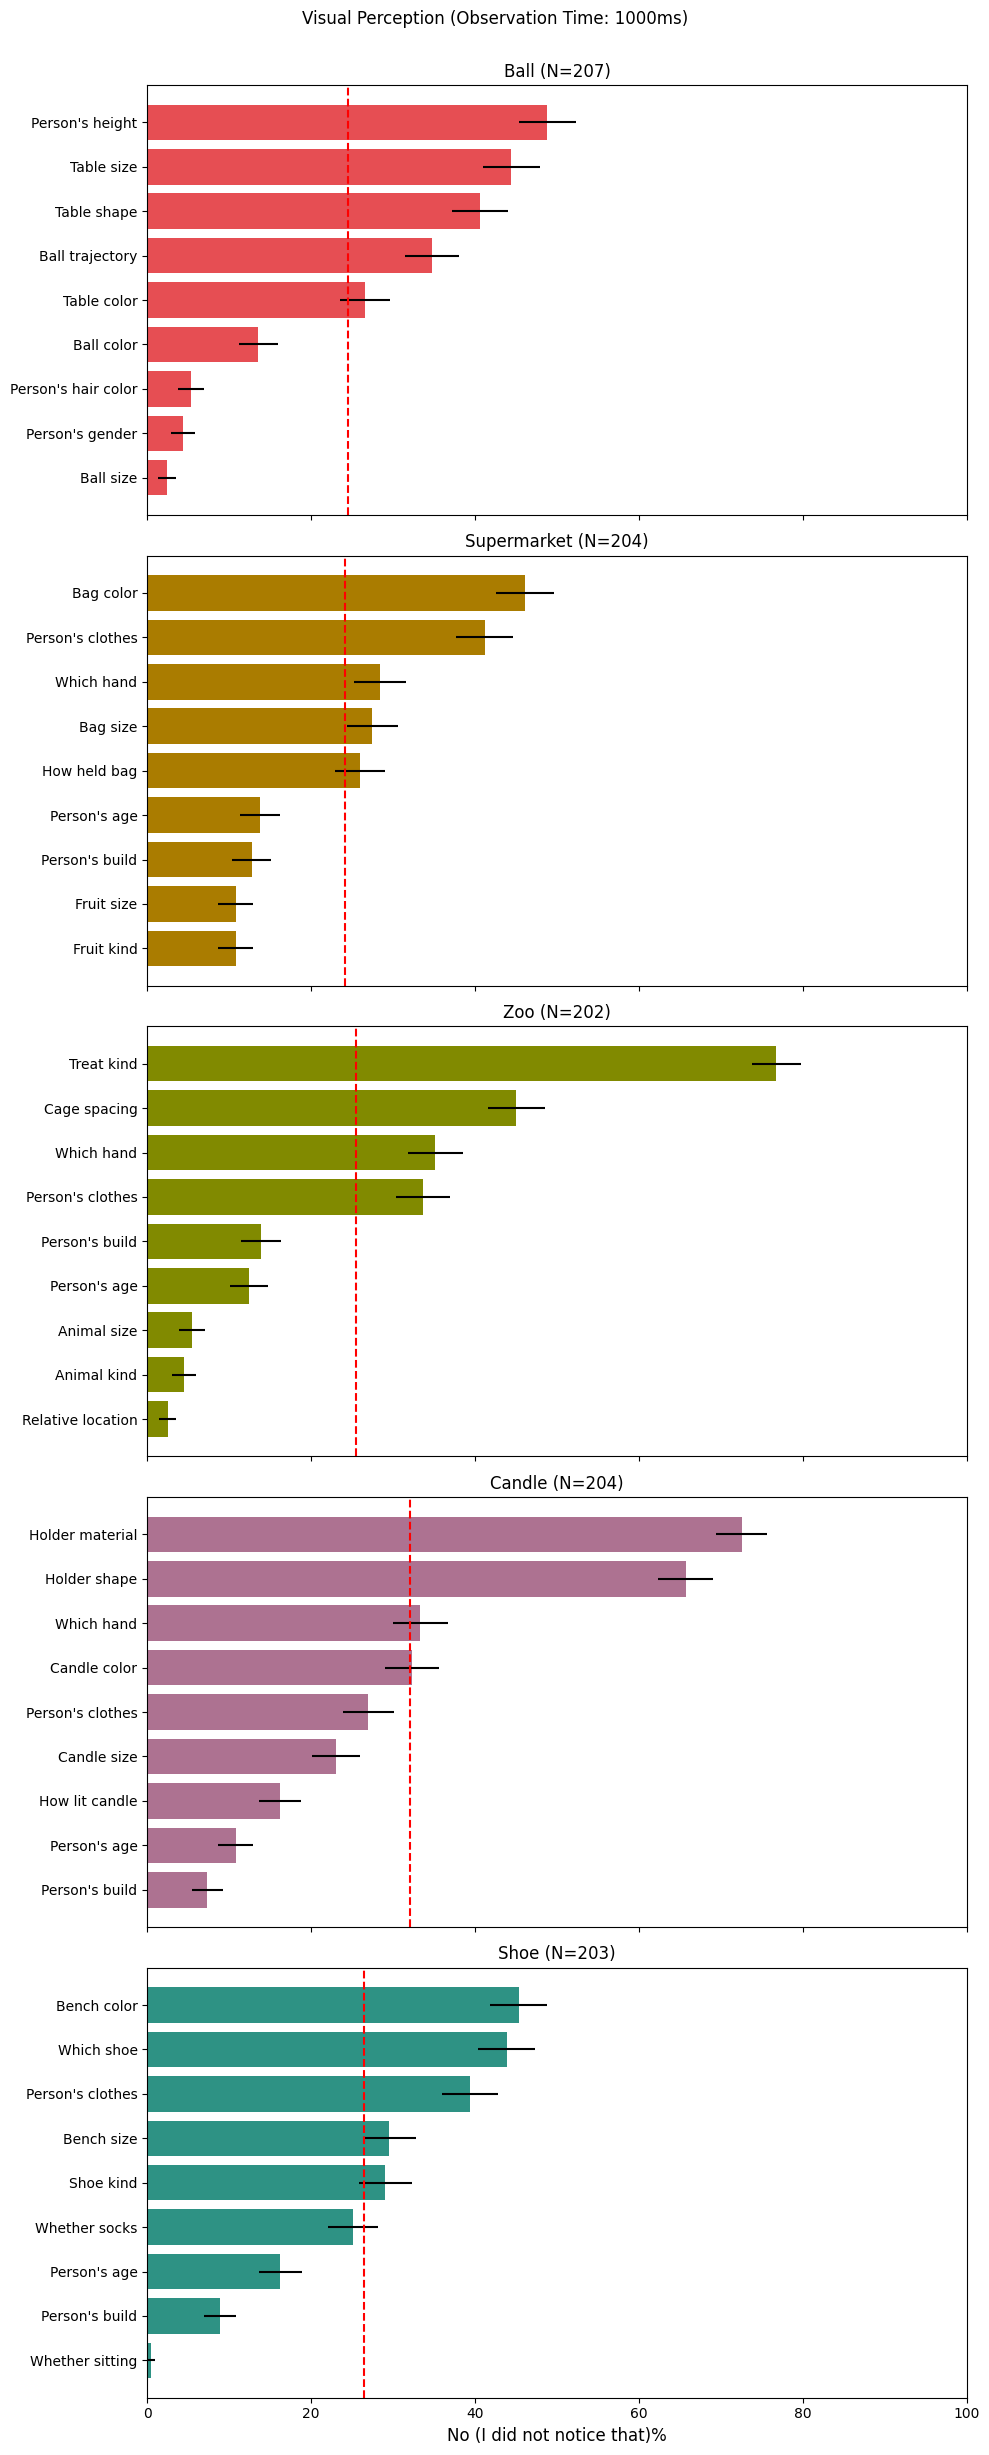

In [ ]:
# No%, sorted

# Prepare figure for subplots
fig, axs = plt.subplots(len(scenes), 1, figsize=(10, 5*len(scenes)), sharex=True)  # 5 Rows, 1 Column

for i in range(len(scenes)):
    # Data for this subplot
    start_index = i * 9
    end_index = start_index + 9

    current_data = df.iloc[:, start_index:end_index].copy()
    # Drop NaN values from the current data
    current_data_nonan = current_data.dropna()

    # Calculate the percentage of 0's after dropping NaNs
    percentage_zeros = (current_data_nonan == 0).sum() / current_data_nonan.count() * 100
    # Calculate SEM, adjusting for the actual number of non-NaN observations
    sem_values = sem((current_data_nonan == 0) * 100, axis=0)

    # Sort the data, SEM values, and labels in descending order
    sorted_indices = percentage_zeros.argsort() # Get indices to sort in descending order
    data_for_subplot = percentage_zeros[sorted_indices]
    sem_values = sem_values[sorted_indices]

    current_index_section = current_data.columns[sorted_indices]  # Use original column names
    final_labels = [property_dict.get(label, label) for label in current_index_section]

    # y-coordinates for bars, after sorting
    y = range(len(data_for_subplot))

    # Plotting horizontal bars for this subplot
    axs[i].barh(y, data_for_subplot, color=colors[i], xerr=sem_values)

    # Set y-ticks and labels for this subplot
    axs[i].set_yticks(y)
    axs[i].set_yticklabels(final_labels)

    # Optional: Add dashed line for average or other stylistic choices
    avg = data_for_subplot.mean()
    axs[i].axvline(x=avg, color='red', linestyle='dashed', label='Average' if i==0 else '')  # label only on the first subplot

    # Optional: Add titles or labels
    axs[i].set_title(scenes[i]+" (N="+str(len(current_data_nonan))+")")

    # set x-axis range
    axs[i].set_xlim(0, 100)


# Adjust layout
plt.xlabel("No (I did not notice that)%", fontsize=12)
plt.tight_layout()
fig.suptitle("Visual Perception (Observation Time: "+version+")")
plt.subplots_adjust(top=0.95)  # Adjust the top padding to make space for the main title
plt.show()


# Save to temporary mini data files

In [ ]:
for i in range(len(scenes)):
    # Define the start and end index for slicing the DataFrame
    start_index = i * 9
    end_index = start_index + 9

    # Slice the DataFrame to get 9 columns
    df_slice = df.iloc[:, start_index:end_index]
    df_slice = df_slice.dropna() # drop nan rows
    df_slice = df_slice.astype(int)

    # Replace the column names in the slice with names from property_dict
    df_slice.columns = [datacol_dict.get(col, col) for col in df_slice.columns]

    # Define the filename for the current slice
    filename = 'formaldata_'+version+'_'+scenes[i]+'.csv'

    # Save the slice to a CSV file
    df_slice.to_csv(filename, index=False)

    print(f'Saved {filename}')

Saved formaldata_1000ms_Ball.csv
Saved formaldata_1000ms_Supermarket.csv
Saved formaldata_1000ms_Zoo.csv
Saved formaldata_1000ms_Candle.csv
Saved formaldata_1000ms_Shoe.csv


# Plot correlation of old and new, 1 scene per row


Scene:  Ball
Slope: 0.023669254351400576
Intercept: 23.741352283831468
R-squared: 0.0007855864064124265
p-value: 0.9429385536651018
Standard error: 0.31905673873746815
95% CI for slope: -0.7307800477013197, 0.7781185564041208
95% CI for intercept: 23.263943053498252, 24.218761514164683


/tmp/ipython-input-2138949970.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
/tmp/ipython-input-2138949970.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
/tmp/ipython-input-2138949970.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
/tmp/ipython-input-2138949970.py:60: FutureWarning: Series._


Scene:  Supermarket
Slope: 0.45356264035427607
Intercept: 7.228114199778613
R-squared: 0.4832666564356094
p-value: 0.03762618893896059
Standard error: 0.17726707647112244
95% CI for slope: 0.03439261232170726, 0.8727326683868448
95% CI for intercept: 6.921956767296973, 7.5342716322602525


/tmp/ipython-input-2138949970.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
/tmp/ipython-input-2138949970.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
/tmp/ipython-input-2138949970.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
/tmp/ipython-input-2138949970.py:60: FutureWarning: Series._


Scene:  Zoo
Slope: 0.5010065686801239
Intercept: 6.274757805237883
R-squared: 0.23798133006234934
p-value: 0.18278960027005636
Standard error: 0.33884865192064006
95% CI for slope: -0.30024317127094347, 1.3022563086311914
95% CI for intercept: 5.7491682733224865, 6.800347337153279


/tmp/ipython-input-2138949970.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
/tmp/ipython-input-2138949970.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
/tmp/ipython-input-2138949970.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
/tmp/ipython-input-2138949970.py:60: FutureWarning: Series._


Scene:  Candle
Slope: -0.49813442458232887
Intercept: 49.9799107796655
R-squared: 0.20040113884422953
p-value: 0.22693040381090657
Standard error: 0.37608284745949166
95% CI for slope: -1.3874290462931127, 0.3911601971284549
95% CI for intercept: 49.35450402897706, 50.60531753035394


/tmp/ipython-input-2138949970.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
/tmp/ipython-input-2138949970.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
/tmp/ipython-input-2138949970.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
/tmp/ipython-input-2138949970.py:60: FutureWarning: Series._


Scene:  Shoe
Slope: 0.6506501168093551
Intercept: 2.0012550001329537
R-squared: 0.39926035479155386
p-value: 0.06791613864501059
Standard error: 0.3016570952431223
95% CI for slope: -0.06265556626756619, 1.3639557998862766
95% CI for intercept: 1.3300899218019846, 2.6724200784639227


/tmp/ipython-input-2138949970.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
/tmp/ipython-input-2138949970.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
/tmp/ipython-input-2138949970.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
/tmp/ipython-input-2138949970.py:60: FutureWarning: Series._

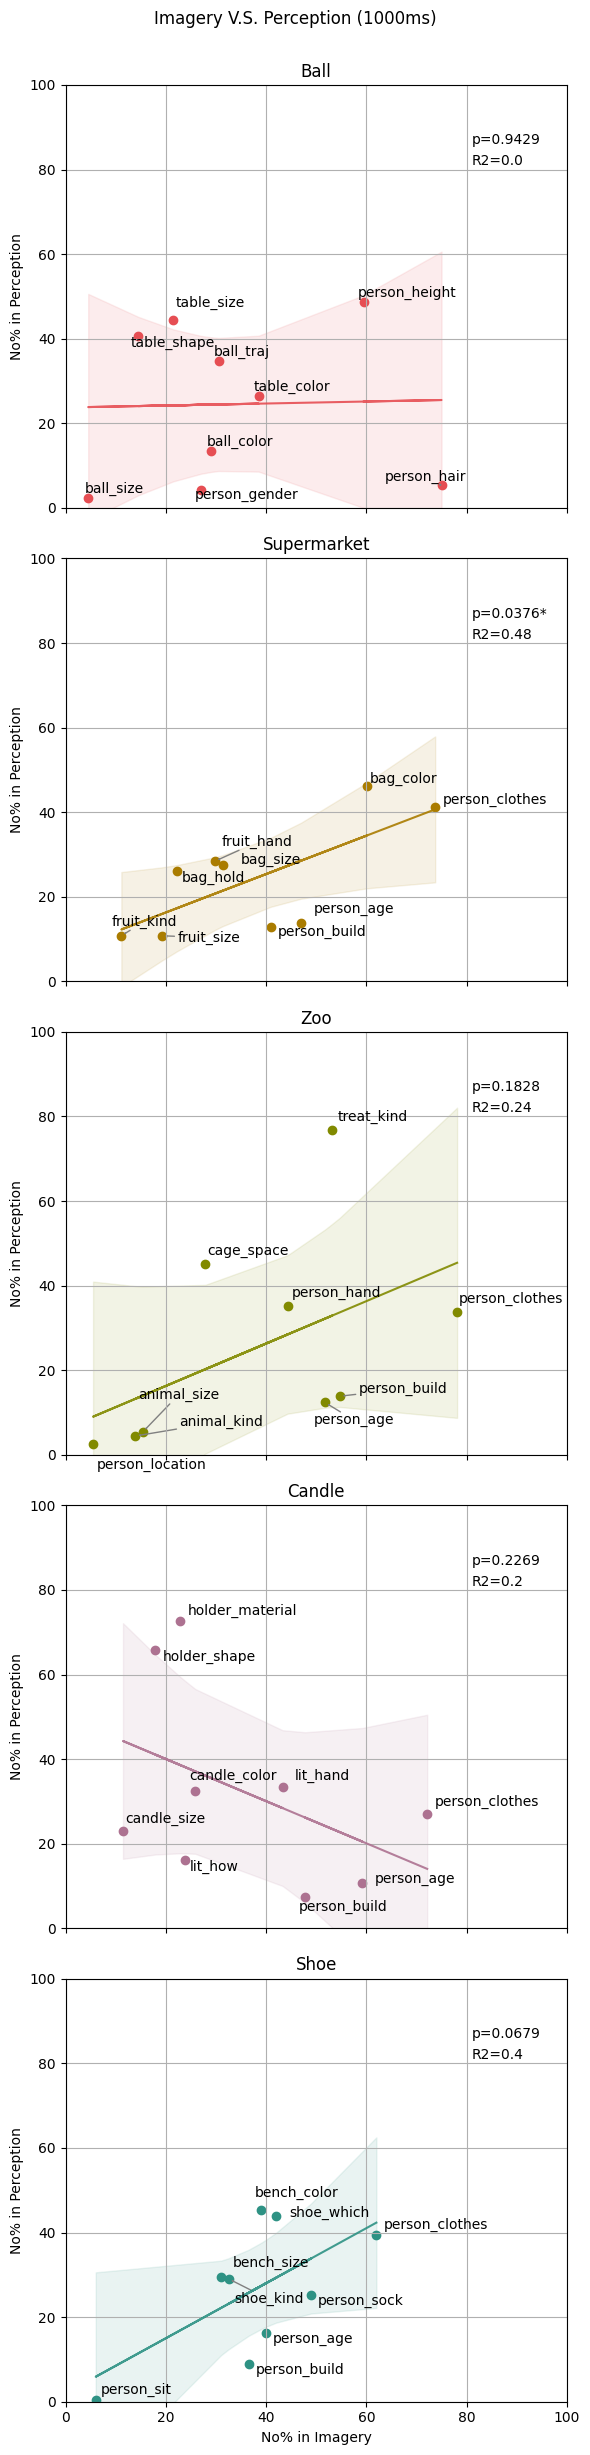

In [ ]:
# Prepare figure for subplots
nrows = len(scenes)
# nrows = 2
fig, axs = plt.subplots(nrows, 1, figsize=(6, 5*nrows), sharex=True)  # 5 Rows, 1 Column

for scene_idx in range(nrows):
    print('\nScene: ', scenes[scene_idx])
    # load data from old and new exp
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns] # Align the columns of newdf with olddf

    # Calculate the average number of 0s for each column
    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100

    # scatter plot of the means
    axs[scene_idx].scatter(avg_zeros_olddf, avg_zeros_newdf, color=colors[scene_idx])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(avg_zeros_olddf, avg_zeros_newdf)
    # Plot the regression line
    axs[scene_idx].plot(avg_zeros_olddf, intercept + slope * avg_zeros_olddf, label=f'y={slope:.2f}x+{intercept:.2f}', color=colors[scene_idx], alpha=0.9)
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(avg_zeros_olddf) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * avg_zeros_olddf # Predicted values
    se = np.sqrt(np.sum((avg_zeros_newdf - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(avg_zeros_olddf) + (avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2)) # Confidence interval calculation
    # Sort the values by avg_zeros_olddf to ensure proper filling
    sorted_indices = np.argsort(avg_zeros_olddf)
    sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[scene_idx].fill_between(sorted_avg_zeros_olddf, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color=colors[scene_idx], alpha=0.1, label='95% CI')
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}')

    axs[-1].set_xlabel('No% in Imagery')
    axs[scene_idx].set_ylabel('No% in Perception')
    axs[scene_idx].set_title(scenes[scene_idx])
    texts = []
    for i, txt in enumerate(avg_zeros_olddf.index): # Annotate each point with its column name
        texts.append(axs[scene_idx].annotate(txt, (avg_zeros_olddf[i], avg_zeros_newdf[i])))
    # Use adjust_text to repel text annotations from each other
    adjust_text(texts, ax=axs[scene_idx], force_static=(1,1), force_text=(2,1), force_pull=(0.1,0.1), min_arrow_len=10, arrowprops=dict(arrowstyle='->', color='gray'))

    # axs[scene_idx].legend(loc='upper left')
    axs[scene_idx].set_ylim(0,100)
    axs[scene_idx].set_xlim(0,100)
    axs[scene_idx].grid(True)

    # annotate p-value and R
    txt = 'p='+str(round(p_value, 4))
    if p_value < 0.001:
        txt += '***'
    elif p_value < 0.01:
        txt += '**'
    elif p_value < 0.05:
        txt += '*'
    axs[scene_idx].annotate(txt, (81,86))
    axs[scene_idx].annotate('R2='+str(round(r_value**2, 2)), (81,81))


    '''
    # Calculate the Hamming distance for each pair of participants (one from each experiment)
    hamming_distances = []
    for index1, row1 in olddf.iterrows():
        for index2, row2 in newdf.iterrows():
            distance = hamming(row1, row2)
            hamming_distances.append(distance)
    observed_distances = np.array(hamming_distances)
    # Generate a distribution of chance-level distances
    num_questions = len(newdf.columns)
    num_comparisons = len(observed_distances)
    olddf_average_response = olddf.mean().mean()
    newdf_average_response = newdf.mean().mean()
    print('olddf_average_response', olddf_average_response, 'newdf_average_response', newdf_average_response)
    # Generate random responses for Experiment 1 based on the average response score
    random_responses_exp1 = np.random.choice([0, 1], size=(num_comparisons, num_questions), p=[1-olddf_average_response, olddf_average_response])
    # Generate random responses for Experiment 2 assuming same distribution as Experiment 1
    random_responses_exp2 = np.random.choice([0, 1], size=(num_comparisons, num_questions), p=[1-olddf_average_response, olddf_average_response])
    # Calculate the Hamming distances between the generated random responses
    chance_distances = np.array([hamming(resp1, resp2) for resp1, resp2 in zip(random_responses_exp1, random_responses_exp2)])
    # Assuming binary responses and chance level of agreement is 50%
    # chance_distances = np.random.binomial(num_questions, 0.5, num_comparisons) / num_questions
    # Perform the Mann-Whitney U Test
    stat, p_value = mannwhitneyu(observed_distances, chance_distances, alternative='two-sided')
    print(f'Mann-Whitney U Test results: U = {stat}, p-value = {p_value}') # if significant, two distributions are different
    '''
    '''
    # Plotting the density plot of distances
    sns.kdeplot(observed_distances, label='Observed', fill=True, ax=axs[scene_idx,1]) # observed distances
    sns.kdeplot(chance_distances, label='Chance', fill=True, color='red', ax=axs[scene_idx,1]) # chance level distances
    # Adding a vertical line for the mean of the distribution
    axs[scene_idx][1].axvline(x=np.mean(observed_distances), color='blue', linestyle='--', label='Mean Observed') # observed distances
    axs[scene_idx][1].axvline(x=np.mean(chance_distances), color='red', linestyle='--', label='Mean Chance') # chance level distances
    axs[scene_idx][1].set_ylim(0,6)
    axs[scene_idx][1].set_xlim(-0.2,1.2)
    axs[scene_idx][1].set_xlabel('Hamming_Distance(Imagery Response, Perception Response)')
    axs[scene_idx][1].set_ylabel('Density')
    # axs[scene_idx][1].set_title('Hamming_Distance(Imagery Response, Perception Response)')
    axs[scene_idx][1].legend()
    '''

plt.tight_layout()
fig.suptitle("Imagery V.S. Perception ("+version+")")
plt.subplots_adjust(top=0.95)  # Adjust the top padding to make space for the main title


# plot correlation of old and new, 1 scene per column

Text(0.5, -0.04, 'No% in Imagery')

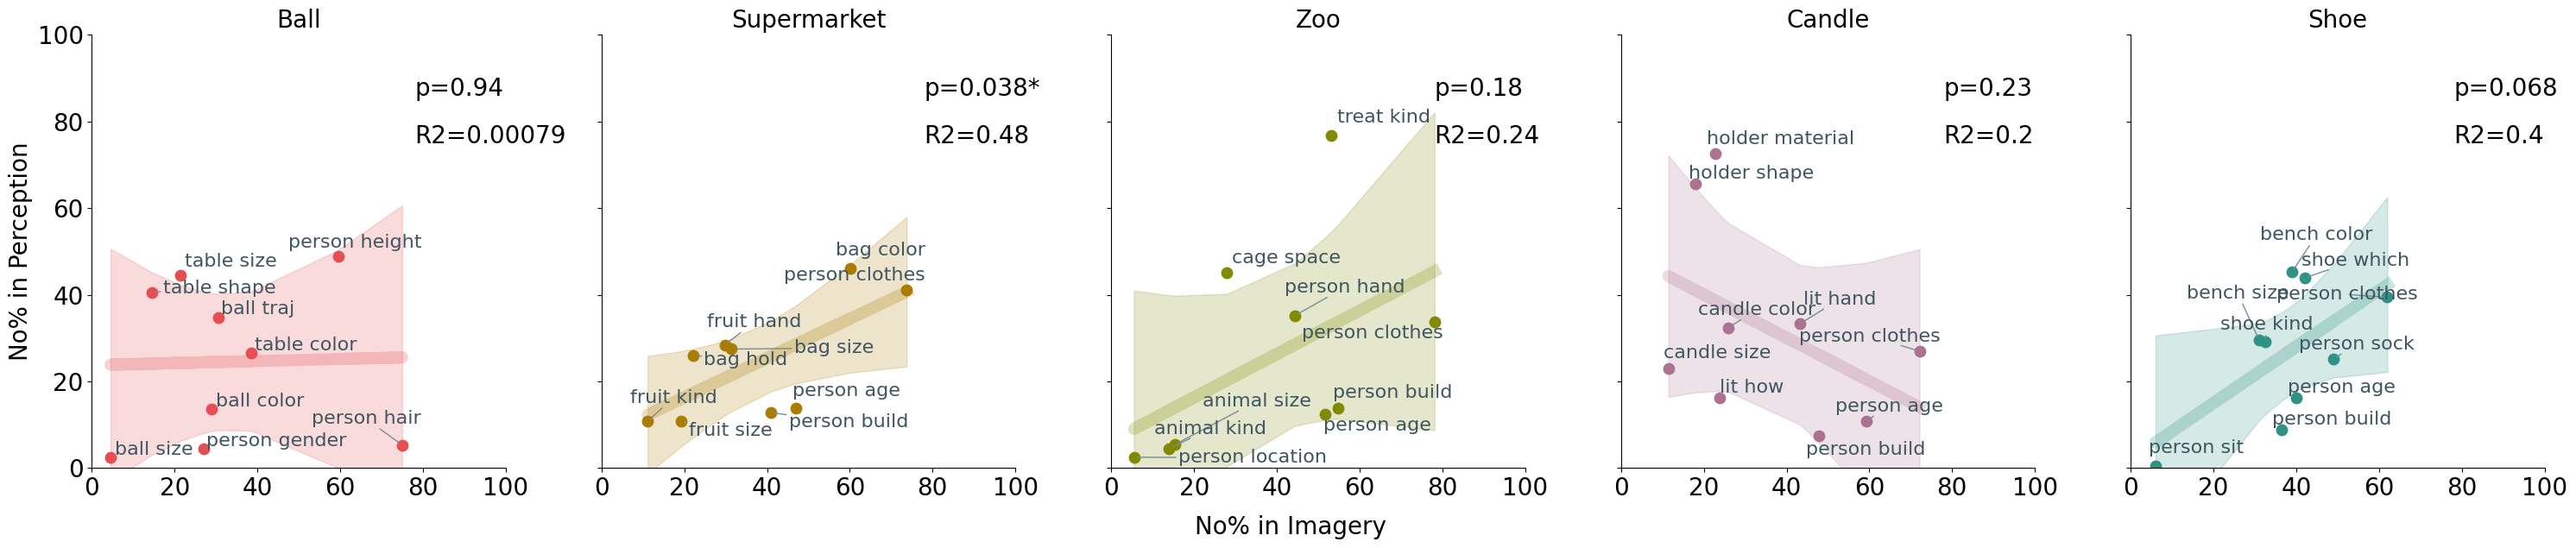

In [ ]:
# suppress warning
import warnings
warnings.filterwarnings('ignore')

# Prepare figure for subplots
ncols = len(scenes)
fig, axs = plt.subplots(1, ncols, figsize=(6*ncols, 6), sharey=True)  # 5 Rows, 1 Column

for scene_idx in range(ncols):
    # print('\nScene: ', scenes[scene_idx])
    # load data from old and new exp
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns] # Align the columns of newdf with olddf

    # Calculate the average number of 0s for each column
    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100

    # scatter plot of the means
    axs[scene_idx].scatter(avg_zeros_olddf, avg_zeros_newdf,
                           color=colors[scene_idx], s=80, alpha=1)

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(avg_zeros_olddf, avg_zeros_newdf)
    # Plot the regression line
    axs[scene_idx].plot(avg_zeros_olddf, intercept + slope * avg_zeros_olddf,
                        color=colors[scene_idx], alpha=0.25, lw=10,
                        label=f'y={slope:.2f}x+{intercept:.2f}')

    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(avg_zeros_olddf) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * avg_zeros_olddf # Predicted values
    se = np.sqrt(np.sum((avg_zeros_newdf - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(avg_zeros_olddf) + (avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2)) # Confidence interval calculation

    # Sort the values by avg_zeros_olddf to ensure proper filling
    sorted_indices = np.argsort(avg_zeros_olddf)
    sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]

    # Plotting the confidence interval
    axs[scene_idx].fill_between(sorted_avg_zeros_olddf, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci,
                                color=colors[scene_idx], alpha=0.2,
                                label='95% CI')
    # print(f'Slope: {slope}')
    # print(f'Intercept: {intercept}')
    # print(f'R-squared: {r_value**2}')
    # print(f'p-value: {p_value}')
    # print(f'Standard error: {std_err}')
    # print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    # print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}')

    axs[0].set_ylabel('No% in Perception', fontsize=20)
    axs[scene_idx].set_title(scenes[scene_idx], fontsize=20)
    texts = []
    for i, txt in enumerate(avg_zeros_olddf.index): # Annotate each point with its column name
        # remove the underscore in the text
        txt = txt.replace('_', ' ')
        texts.append(axs[scene_idx].annotate(txt, (avg_zeros_olddf[i], avg_zeros_newdf[i]), fontsize=16, color=textcolor))
    # Use adjust_text to repel text annotations from each other
    adjust_text(texts, ax=axs[scene_idx],
                force_static=(5,5), force_text=(10,10), #force_pull=(0.1, 0.1),
                # force_explode=(-3,-1),
                # force_text=(10,10),
                min_arrow_len=10, arrowprops=dict(arrowstyle='->', color=graycolor))

    axs[scene_idx].set_ylim(0,100)
    axs[scene_idx].set_xlim(0,100)
    axs[scene_idx].spines['top'].set_visible(False) # no top border
    axs[scene_idx].spines['right'].set_visible(False) # no right border
    axs[scene_idx].tick_params(axis='both', labelsize=20)

    # annotate p-value and R
    txt = f'p={p_value:.2g}'
    if p_value < 0.001:
        txt += '***'
    elif p_value < 0.01:
        txt += '**'
    elif p_value < 0.05:
        txt += '*'
    axs[scene_idx].annotate(txt, (78,86), fontsize=20)
    axs[scene_idx].annotate(f'R2={r_value**2:.2g}', (78,75), fontsize=20)

plt.tight_layout()
fig.text(0.5, -0.04, 'No% in Imagery', ha='center', fontsize=20)


# Bayesian Analysis of Correlation

In [ ]:
import pymc as pm
import pytensor.tensor as tt # Use pytensor.tensor instead of theano.tensor
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine all data into a single DataFrame
all_data = []
for scene_idx in range(len(scenes)):
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx != 0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()]
        matching_rows = matching_rows.dropna(axis=1, how='all')
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns]
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns]

    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100

    temp_df = pd.DataFrame({
        'imagery_no_percent': avg_zeros_olddf,
        'perception_no_percent': avg_zeros_newdf,
        'scene': scenes[scene_idx]
    })
    all_data.append(temp_df)

combined_df = pd.concat(all_data).reset_index(drop=True)
display(combined_df.head())

,imagery_no_percent,perception_no_percent,scene
0,29.0,13.526570,Ball
1,4.5,2.415459,Ball
2,30.5,34.782609,Ball
3,21.5,44.444444,Ball
4,38.5,26.570048,Ball


In [ ]:
# Define the Bayesian model using PyMC
with pm.Model() as correlation_model:
    # Priors for the parameters
    # Using Flat for intercept and slope for minimal prior influence
    intercept = pm.Flat('intercept')
    slope = pm.Flat('slope')
    # Prior for the standard deviation, half-normal is a common choice for non-negative parameters
    sigma = pm.HalfNormal('sigma', sigma=10) # Changed 'sd' to 'sigma'

    # Expected value of the perception No%
    mu = intercept + slope * combined_df['imagery_no_percent'].values # Use .values to get numpy array

    # Likelihood (sampling distribution) of the observations
    # We assume the observed perception No% are normally distributed around the expected value
    observation = pm.Normal('observation', mu=mu, sigma=sigma, observed=combined_df['perception_no_percent'].values)

    # Sample from the posterior distribution
    # tune: Number of iterations to tune the sampler (discarded)
    # draws: Number of samples to draw from the posterior
    # chains: Number of independent Markov chains to run
    # cores: Number of cores to use for parallel sampling (set to 1 for Colab free tier stability)
    trace = pm.sample(draws=2000, tune=1000, chains=4, cores=1, random_seed=123)

Output()

In [ ]:
# Analyze the results using Arviz
# Print a summary of the posterior distribution for each parameter
display(az.summary(trace, round_to=2))

# Plot the posterior distributions and trace plots
az.plot_trace(trace)
plt.show()

# Plot the posterior predictive checks
# Generate samples from the posterior predictive distribution
with correlation_model:
    ppc = pm.sample_posterior_predictive(trace, samples=500, random_seed=123)

# Plot the observed data and the posterior predictive samples
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc, model=correlation_model)) # az.from_pymc3 still works with pymc v4+
plt.show()

# Plot the joint posterior distribution of the slope and intercept
az.plot_pair(trace, var_names=['slope', 'intercept'], kind='scatter', marginals=True)
plt.show()

NameError: name 'trace' is not defined

In [ ]:
!pip install pymc arviz

The Bayesian analysis provides a posterior distribution for the model parameters (intercept, slope, and sigma), allowing us to quantify the uncertainty in our estimates. The `az.summary` table shows the mean, standard deviation, and credible intervals for these parameters. The trace plots help assess the convergence of the Markov chains, and the posterior predictive checks visualize how well the model fits the observed data. The pair plot shows the joint posterior distribution of the slope and intercept.

# Plot bar of old and new, 1 scene per row

In [ ]:
# Prepare figure for subplots
nrows = len(scenes)
# nrows = 2
fig, axs = plt.subplots(nrows, 1, figsize=(6, 5*nrows))  # 5 Rows, 1 Column

for scene_idx in range(nrows):
    print('\nScene: ', scenes[scene_idx])
    # load data from old and new exp
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns] # Align the columns of newdf with olddf

    tmpdf1 = (olddf.copy() == 0)*100
    tmpdf2 = (newdf.copy() == 0)*100
    sorted_columns = tmpdf1.columns[tmpdf1.mean().argsort()]
    tmpdf1 = tmpdf1[sorted_columns]
    tmpdf1["Exp"] = "Imagery"
    tmpdf2 = tmpdf2[sorted_columns]
    tmpdf2["Exp"] = "Perception"
    aggdf = pd.concat([tmpdf1, tmpdf2], ignore_index=True)
    longdf = aggdf.melt(id_vars=['Exp'], var_name='Property', value_name='No%')
    sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])
    axs[scene_idx].set_ylim(0,100)
    axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)
    axs[scene_idx].set_xlabel('')
    axs[scene_idx].legend(loc='upper left')
    axs[scene_idx].set_title(scenes[scene_idx])


plt.tight_layout()
fig.suptitle("Imagery V.S. Perception ("+version+")")
plt.subplots_adjust(top=0.95)  # Adjust the top padding to make space for the main title
plt.show()

# Plot correlation of all scenes

In [ ]:
plt.figure(figsize=(10,10))
all_scores_old = []
all_scores_new = []
labels = []

for scene_idx in range(len(scenes)):
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)

    # Align the columns of newdf with olddf
    newdf = newdf[olddf.columns]

    # Calculate the average number of 0s for each column
    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100
    all_scores_old += avg_zeros_olddf.tolist()
    all_scores_new += avg_zeros_newdf.tolist()

    # Create scatter plot
    plt.scatter(avg_zeros_olddf, avg_zeros_newdf, label=scenes[scene_idx],
                color=colors[scene_idx], s=80, alpha=1)

    # # Annotate each point with its column name
    # for i, txt in enumerate(avg_zeros_olddf.index):
    #     txt = txt.replace('_', ' ')
    #     labels.append(plt.annotate(txt, (avg_zeros_olddf[i], avg_zeros_newdf[i]), fontsize=16))

# # Use adjust_text to repel text annotations from each other
# adjust_text(labels,
#             # force_static=(1,1), force_text=(1,1), force_pull=(0.1,0.1),
#             force_explode=(-3,-1),
#             force_text=(3,3),
#             min_arrow_len=10, arrowprops=dict(arrowstyle='->', color='gray'))

all_scores_old = np.array(all_scores_old)
all_scores_new = np.array(all_scores_new)
# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(all_scores_old, all_scores_new)
# Plot the regression line
plt.plot(all_scores_old, intercept + slope * all_scores_old,
         color=graycolor, alpha=0.25, lw=10)

# Calculate the confidence intervals
confidence_interval = 0.95  # 95% confidence interval
degrees_freedom = len(all_scores_old) - 2  # Degrees of freedom
t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
# Predicted values
y_pred = intercept + slope * all_scores_old
# Standard error of the regression
se = np.sqrt(np.sum((all_scores_new - y_pred) ** 2) / degrees_freedom)
# Confidence interval calculation
ci = t_crit * se * np.sqrt(1/len(all_scores_old) + (all_scores_old - np.mean(all_scores_old)) ** 2 / np.sum((all_scores_old - np.mean(all_scores_old)) ** 2))
# Sort the values by all_scores_old to ensure proper filling
sorted_indices = np.argsort(all_scores_old)
sorted_all_scores_old = all_scores_old[sorted_indices]
sorted_y_pred = y_pred[sorted_indices]
sorted_ci = ci[sorted_indices]

# Plotting the confidence interval
plt.fill_between(sorted_all_scores_old, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci,
                 color=graycolor, alpha=0.2)

# # Show statistical values
# print(f'Slope: {slope}')
# print(f'Intercept: {intercept}')
# print(f'R-squared: {r_value**2}')
# print(f'p-value: {p_value}')
# print(f'Standard error: {std_err}')
# print(f'95% confidence interval for the slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
# print(f'95% confidence interval for the intercept: {intercept - t_crit * std_err * np.sqrt(1/len(all_scores_old) + np.mean(all_scores_old)**2 / np.sum((all_scores_old - np.mean(all_scores_old)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(all_scores_old) + np.mean(all_scores_old)**2 / np.sum((all_scores_old - np.mean(all_scores_old)) ** 2))}')

# annotate p-value and R
txt = f'p={p_value:.2g}'
if p_value < 0.001:
    txt += '***'
elif p_value < 0.01:
    txt += '**'
elif p_value < 0.05:
    txt += '*'
plt.annotate(txt, (75,70), fontsize=20)
plt.annotate(f'R2={r_value**2:.2g}', (75,64), fontsize=20)

# Add labels and title
plt.xlabel('%Participants reporting "No, it was not part of my mental image."', fontsize=20)
plt.ylabel('%Participants reporting "No, I did not notice that."', fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.legend(loc='upper right', frameon=True, title='Scene', fontsize=16, title_fontsize=16)

plt.ylim(0,100)
plt.xlim(0,100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

# Vividness

In [ ]:
df = pd.read_csv('exp_4a.csv')
df.head()

In [ ]:
df4b = pd.read_csv('exp_4b.csv')
df4b.head()

In [ ]:
properties = ['fruit_size', 'fruit_hand', 'bag_size', 'bag_held', 'fruit_kind', 'bag_color', 'person_age', 'person_build', 'person_clothes']
nrows = len(properties)
fig, axs = plt.subplots(nrows, 3, figsize=(16, 5*nrows))  # 5 Rows, 1 Column

for iproperty in range(nrows):
    xdata = df['vviq_total']
    ydata = df[properties[iproperty]]
    axs[iproperty][0].scatter(xdata, ydata)
    axs[iproperty][0].set_xlabel('vviq_total')
    axs[iproperty][0].set_ylabel(properties[iproperty])
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)
    # Plot the regression line
    axs[iproperty][0].plot(xdata, intercept + slope * xdata, label=f'y={slope:.2f}x+{intercept:.2f}', color='darkgray')
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(xdata) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * xdata # Predicted values
    se = np.sqrt(np.sum((ydata - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(xdata) + (xdata - np.mean(xdata)) ** 2 / np.sum((xdata - np.mean(xdata)) ** 2)) # Confidence interval calculation
    # Sort the values by xdata to ensure proper filling
    sorted_indices = np.argsort(xdata)
    sorted_xdata = xdata[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[iproperty][0].fill_between(sorted_xdata, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color='b', alpha=0.1, label='95% CI')
    if p_value < 0.001:
        axs[iproperty][0].annotate('***', (40, 0.6))
    elif p_value < 0.01:
        axs[iproperty][0].annotate('**', (40, 0.6))
    elif p_value < 0.05:
        axs[iproperty][0].annotate('*', (40, 0.6))
    else:
        axs[iproperty][0].annotate('NS',(40, 0.6))
    axs[iproperty][0].annotate('R2='+str(round(r_value**2, 2)),(40, 0.5))
    axs[iproperty][0].set_ylim(-0.1,1.1)
    axs[iproperty][0].set_xlim(10,80)
    axs[iproperty][0].grid(True)
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}')

    xdata = df['suis_total']
    axs[iproperty][1].scatter(xdata, ydata)
    axs[iproperty][1].set_xlabel('suis_total')
    axs[iproperty][1].set_ylabel(properties[iproperty])
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)
    # Plot the regression line
    axs[iproperty][1].plot(xdata, intercept + slope * xdata, label=f'y={slope:.2f}x+{intercept:.2f}', color='darkgray')
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(xdata) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * xdata # Predicted values
    se = np.sqrt(np.sum((ydata - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(xdata) + (xdata - np.mean(xdata)) ** 2 / np.sum((xdata - np.mean(xdata)) ** 2)) # Confidence interval calculation
    # Sort the values by xdata to ensure proper filling
    sorted_indices = np.argsort(xdata)
    sorted_xdata = xdata[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[iproperty][1].fill_between(sorted_xdata, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color='b', alpha=0.1, label='95% CI')
    if p_value < 0.001:
        axs[iproperty][1].annotate('***', (30, 0.6))
    elif p_value < 0.01:
        axs[iproperty][1].annotate('**', (30, 0.6))
    elif p_value < 0.05:
        axs[iproperty][1].annotate('*', (30, 0.6))
    else:
        axs[iproperty][1].annotate('NS', (30, 0.6))
    axs[iproperty][1].annotate('R2='+str(round(r_value**2,2)), (30, 0.5))
    axs[iproperty][1].set_ylim(-0.1,1.1)
    axs[iproperty][1].set_xlim(10,60)
    axs[iproperty][1].grid(True)
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}')

    xdata = df4b['scene_clarity']
    ydata = df4b[properties[iproperty]]
    axs[iproperty][2].scatter(xdata, ydata)
    axs[iproperty][2].set_xlabel('scene_clarity')
    axs[iproperty][2].set_ylabel(properties[iproperty])
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)
    # Plot the regression line
    axs[iproperty][2].plot(xdata, intercept + slope * xdata, label=f'y={slope:.2f}x+{intercept:.2f}', color='darkgray')
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(xdata) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * xdata # Predicted values
    se = np.sqrt(np.sum((ydata - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(xdata) + (xdata - np.mean(xdata)) ** 2 / np.sum((xdata - np.mean(xdata)) ** 2)) # Confidence interval calculation
    # Sort the values by xdata to ensure proper filling
    sorted_indices = np.argsort(xdata)
    sorted_xdata = xdata[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[iproperty][2].fill_between(sorted_xdata, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color='b', alpha=0.1, label='95% CI')
    if p_value < 0.001:
        axs[iproperty][2].annotate('***', (3, 0.6))
    elif p_value < 0.01:
        axs[iproperty][2].annotate('**', (3, 0.6))
    elif p_value < 0.05:
        axs[iproperty][2].annotate('*', (3, 0.6))
    else:
        axs[iproperty][2].annotate('NS', (3, 0.6))
    axs[iproperty][2].annotate('R2='+str(round(r_value**2,2)), (3, 0.5))
    axs[iproperty][2].set_ylim(-0.1,1.1)
    axs[iproperty][2].set_xlim(1,7.5)
    axs[iproperty][2].grid(True)
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}')




# Show the plot
plt.show()